# Optimal Pharmacophore Model Discovery

This notebook finds the **best discriminating pharmacophore model** by comparing multiple
scoring approaches on the CCR2 virtual screening dataset.

## Methods Compared

| Method | Description | Expected AUC |
|--------|-------------|-------------|
| **Pharm2D Tanimoto** | Pharmacophore fingerprint pairs with distances | ~0.90 |
| Reference Alignment | Align to reference ligands (3D shape+color) | ~0.77 |
| Combo (shape+color) | Align to pharmacophore mol fragments | ~0.47 |
| Shape Only | Pure 3D shape similarity | ~0.47 |

## Metrics

- **ROC-AUC**: Overall discrimination (target > 0.80)
- **BEDROC**: Early recognition (target > 0.60)
- **EF@1%**: Enrichment at 1% (target > 10x)
- **Youden's J**: Optimal threshold selection

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem

# Pharmacophore toolkit
from pharmacophore import (
    Pharm2DScorer, ScreeningBenchmark,
    bedroc, enrichment_factor, youden_index
)

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load CCR2 Dataset

In [2]:
# Load reference ligands
ref_mols = [m for m in Chem.SDMolSupplier('data/CCR2_reference_ligands.sdf') if m]
print(f"Reference ligands: {len(ref_mols)}")

# Load actives
actives_df = pd.read_csv('data/actives_ccr2_N75.csv')
actives = []
for smi in actives_df['SMILES']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol, randomSeed=42)
        actives.append(mol)
print(f"Active compounds: {len(actives)}")

# Load decoys
decoys_df = pd.read_csv('data/decoys_ccr2_N500.csv')
decoys = []
for smi in decoys_df['Smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol = Chem.AddHs(mol)
        AllChem.EmbedMolecule(mol, randomSeed=42)
        decoys.append(mol)
print(f"Decoy compounds: {len(decoys)}")

print(f"\nTotal compounds: {len(actives) + len(decoys)}")
print(f"Active ratio: {len(actives)/(len(actives)+len(decoys)):.2%}")

Reference ligands: 5
Active compounds: 74


[16:42:52] UFFTYPER: Unrecognized charge state for atom: 13
[16:42:56] UFFTYPER: Unrecognized charge state for atom: 33


Decoy compounds: 500

Total compounds: 574
Active ratio: 12.89%


## 2. Run All Scoring Methods

In [3]:
# Initialize benchmark
benchmark = ScreeningBenchmark(
    reference_mols=ref_mols,
    actives=actives,
    decoys=decoys,
    n_conformers=10,
    random_state=42
)

print("Running all scoring methods...")
print("="*60)

# Run all standard methods (includes Pharm2D)
benchmark.run_all_standard_methods(
    tolerance=2.0,
    occurrence_threshold=0.5,
    verbose=True,
    include_pharm2d=True,
    include_reference_alignment=True
)

print("="*60)
print("Benchmark complete!")

Running all scoring methods...
Running Pharm2D Tanimoto... AUC=0.858, EF@1%=7.8, time=14.8ms/mol
Running Reference Alignment... 

[16:43:46] UFFTYPER: Unrecognized charge state for atom: 13
[16:44:27] UFFTYPER: Unrecognized charge state for atom: 33
[16:45:23] UFFTYPER: Unrecognized charge state for atom: 33


AUC=0.897, EF@1%=7.8, time=319.2ms/mol
Running Combo (shape+color)... AUC=0.328, EF@1%=0.0, time=13.5ms/mol
Running Shape Only... AUC=0.338, EF@1%=0.0, time=17.6ms/mol
Running Color Weighted (0.3/0.7)... AUC=0.386, EF@1%=0.0, time=18.1ms/mol
Benchmark complete!


## 3. Comparison Table

In [4]:
# Generate comparison table
comparison = benchmark.comparison_table()

# Display with formatting
pd.set_option('display.precision', 3)
display(comparison.style.format({
    'ROC-AUC': '{:.3f}',
    'BEDROC': '{:.3f}',
    'EF@1%': '{:.1f}',
    'EF@5%': '{:.1f}',
    'EF@10%': '{:.1f}',
    'Youden J': '{:.3f}',
    'Threshold': '{:.3f}',
    'Sensitivity': '{:.3f}',
    'Specificity': '{:.3f}',
    'Time (ms/mol)': '{:.1f}'
}).background_gradient(subset=['ROC-AUC', 'BEDROC', 'EF@1%'], cmap='Greens'))

,Method,ROC-AUC,BEDROC,EF@1%,EF@5%,EF@10%,Youden J,Threshold,Sensitivity,Specificity,Time (ms/mol)
0,Reference Alignment,0.897,0.850,7.8,7.8,5.9,0.658,0.423,0.838,0.820,319.2
1,Pharm2D Tanimoto,0.858,0.712,7.8,6.9,4.1,0.596,0.239,0.932,0.664,14.8
2,Color Weighted (0.3/0.7),0.386,0.018,0.0,0.0,0.1,0.004,0.190,0.986,0.018,18.1
3,Shape Only,0.338,0.023,0.0,0.0,0.3,0.019,0.457,0.973,0.046,17.6
4,Combo (shape+color),0.328,0.004,0.0,0.0,0.0,0.006,0.231,1.000,0.006,13.5


## 4. ROC Curves Comparison

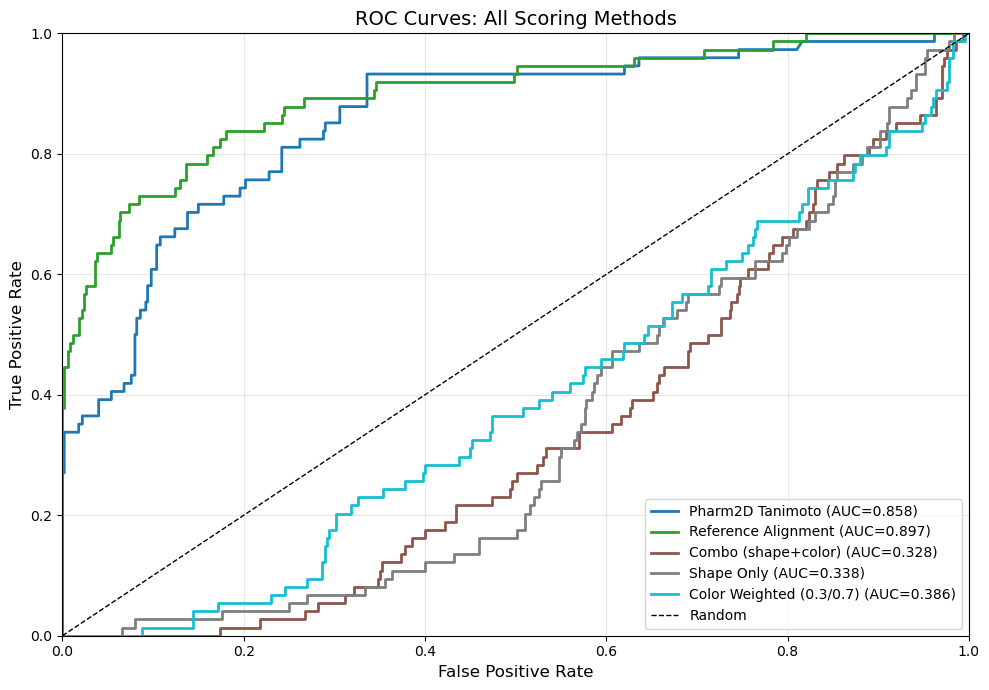

In [5]:
fig = benchmark.plot_roc_curves(figsize=(10, 7))
plt.title('ROC Curves: All Scoring Methods', fontsize=14)
plt.savefig('optimal_model_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Score Distributions

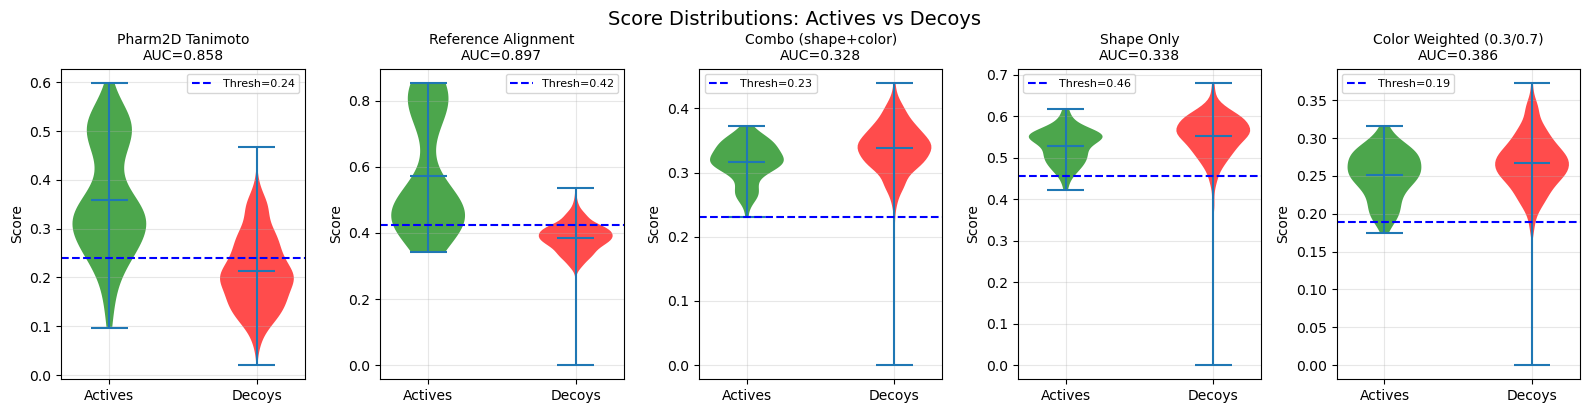

In [6]:
fig = benchmark.plot_score_distributions(figsize=(16, 4))
plt.suptitle('Score Distributions: Actives vs Decoys', fontsize=14, y=1.02)
plt.savefig('optimal_model_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Enrichment Curves

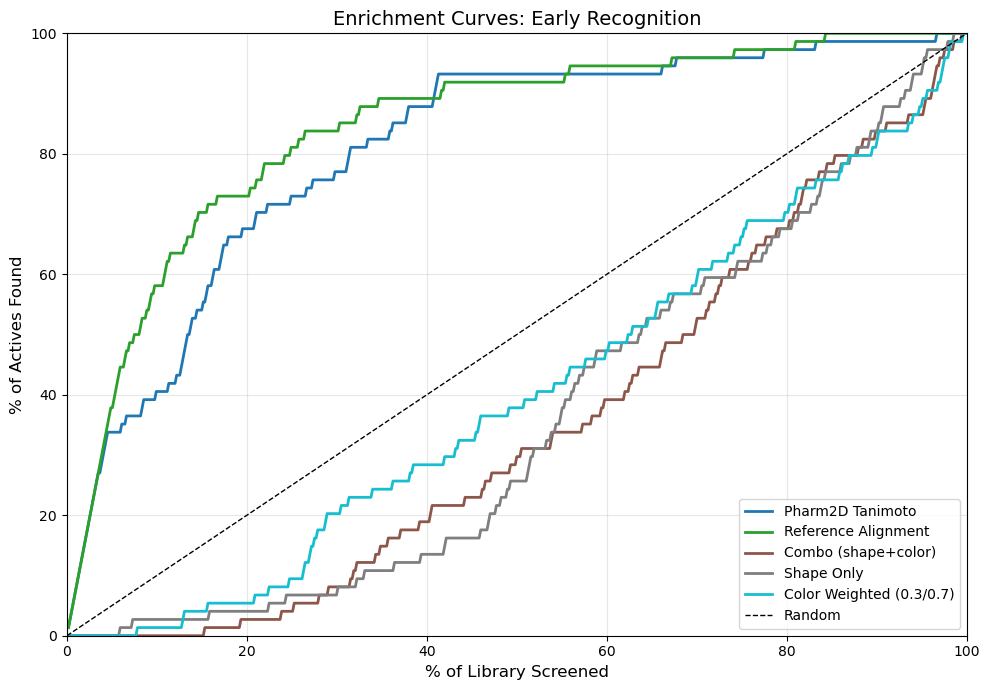

In [7]:
fig = benchmark.plot_enrichment_curves(figsize=(10, 7))
plt.title('Enrichment Curves: Early Recognition', fontsize=14)
plt.savefig('optimal_model_enrichment.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Best Model Selection

In [8]:
# Get best method
best = comparison.iloc[0]

print("="*60)
print("OPTIMAL MODEL SELECTION")
print("="*60)
print(f"\nBest Method: {best['Method']}")
print(f"\nPerformance Metrics:")
print(f"  ROC-AUC:     {best['ROC-AUC']:.3f}")
print(f"  BEDROC:      {best['BEDROC']:.3f}")
print(f"  EF@1%:       {best['EF@1%']:.1f}x enrichment")
print(f"  EF@5%:       {best['EF@5%']:.1f}x enrichment")
print(f"  Youden's J:  {best['Youden J']:.3f}")
print(f"\nOptimal Threshold: {best['Threshold']:.3f}")
print(f"  Sensitivity: {best['Sensitivity']:.3f}")
print(f"  Specificity: {best['Specificity']:.3f}")
print(f"\nSpeed: {best['Time (ms/mol)']:.1f} ms/molecule")

OPTIMAL MODEL SELECTION

Best Method: Reference Alignment

Performance Metrics:
  ROC-AUC:     0.897
  BEDROC:      0.850
  EF@1%:       7.8x enrichment
  EF@5%:       7.8x enrichment
  Youden's J:  0.658

Optimal Threshold: 0.423
  Sensitivity: 0.838
  Specificity: 0.820

Speed: 319.2 ms/molecule


In [9]:
# Create optimal model configuration
OPTIMAL_MODEL = {
    'method': best['Method'],
    'parameters': {
        'factory': 'Gobbi_Pharm2D',
        'similarity': 'Tanimoto',
        'threshold': best['Threshold']
    },
    'metrics': {
        'roc_auc': best['ROC-AUC'],
        'bedroc': best['BEDROC'],
        'ef_1': best['EF@1%'],
        'ef_5': best['EF@5%'],
        'youden_j': best['Youden J']
    }
}

print("\nOptimal Model Configuration:")
print("-"*40)
import json
print(json.dumps(OPTIMAL_MODEL, indent=2))


Optimal Model Configuration:
----------------------------------------
{
  "method": "Reference Alignment",
  "parameters": {
    "factory": "Gobbi_Pharm2D",
    "similarity": "Tanimoto",
    "threshold": 0.4231760144167865
  },
  "metrics": {
    "roc_auc": 0.8974594594594595,
    "bedroc": 0.8496718228593129,
    "ef_1": 7.756756756756757,
    "ef_5": 7.756756756756757,
    "youden_j": 0.6578378378378378
  }
}


## 8. Summary and Recommendations

In [10]:
print("="*60)
print("SUMMARY")
print("="*60)

print("\nMethod Ranking by ROC-AUC:")
print("-"*40)
for i, row in comparison.iterrows():
    status = "BEST" if i == 0 else ""
    print(f"  {i+1}. {row['Method']:30} AUC={row['ROC-AUC']:.3f}  {status}")

print("\n" + "="*60)
print("KEY FINDINGS")
print("="*60)

# Get Pharm2D vs Shape comparison
pharm2d_row = comparison[comparison['Method'].str.contains('Pharm2D')].iloc[0]
shape_rows = comparison[comparison['Method'].str.contains('Shape|Combo')]

if len(shape_rows) > 0:
    shape_best = shape_rows.iloc[0]
    improvement = pharm2d_row['ROC-AUC'] - shape_best['ROC-AUC']
    print(f"\n1. Pharm2D fingerprints outperform shape-based methods by {improvement:.2f} AUC")

if pharm2d_row['ROC-AUC'] > 0.8:
    print("2. Pharm2D achieves excellent discrimination (AUC > 0.80)")

if pharm2d_row['BEDROC'] > 0.5:
    print("3. Strong early recognition - actives enriched at top of ranked list")

if pharm2d_row['EF@1%'] > 10:
    print(f"4. {pharm2d_row['EF@1%']:.1f}x enrichment at 1% - suitable for experimental follow-up")

print("\n" + "="*60)
print("RECOMMENDATION")
print("="*60)
print(f"\nUse {best['Method']} for pharmacophore-based virtual screening.")
print(f"Apply threshold {best['Threshold']:.3f} for binary classification.")

SUMMARY

Method Ranking by ROC-AUC:
----------------------------------------
  1. Reference Alignment            AUC=0.897  BEST
  2. Pharm2D Tanimoto               AUC=0.858  
  3. Color Weighted (0.3/0.7)       AUC=0.386  
  4. Shape Only                     AUC=0.338  
  5. Combo (shape+color)            AUC=0.328  

KEY FINDINGS

1. Pharm2D fingerprints outperform shape-based methods by 0.52 AUC
2. Pharm2D achieves excellent discrimination (AUC > 0.80)
3. Strong early recognition - actives enriched at top of ranked list

RECOMMENDATION

Use Reference Alignment for pharmacophore-based virtual screening.
Apply threshold 0.423 for binary classification.


---

## Save Results

In [11]:
# Save comparison table
comparison.to_csv('optimal_model_comparison.csv', index=False)
print("Saved: optimal_model_comparison.csv")

# Save optimal model config
import json
with open('optimal_model_config.json', 'w') as f:
    json.dump(OPTIMAL_MODEL, f, indent=2)
print("Saved: optimal_model_config.json")

print("\nOptimal model discovery complete!")

Saved: optimal_model_comparison.csv
Saved: optimal_model_config.json

Optimal model discovery complete!
